# GCP IAM Agent - LangGraph Workflow

## Overview
This notebook implements an Agentic workflow using LangGraph that generates comprehensive lists of IAM permissions required for service accounts or users to work with specific Google Cloud Platform (GCP) services.

## Services Covered:
- **Vertex AI** - Machine Learning and AI platform
- **Compute Engine** - Virtual machines and infrastructure
- **Cloud Storage** - Object storage service
- **BigQuery** - Data warehouse and analytics
- **Cloud Build** - CI/CD and build service
- **Cloud Run** - Serverless container platform

## Key Features:
1. **Role-Based Permission Generation** - Generates minimal required roles and permissions
2. **Private Network Support** - Ensures access without public IP addresses
3. **Validation System** - Validates permissions before providing recommendations
4. **Service Account Optimization** - Provides both user and service account permissions
5. **Security Best Practices** - Follows principle of least privilege

## Workflow Architecture:
The LangGraph workflow consists of multiple agents that collaborate to:
1. Analyze service requirements
2. Generate minimal permission sets
3. Validate networking constraints
4. Provide security recommendations
5. Output formatted IAM policies

In [1]:
# Import required libraries
import os
import json
from typing import Dict, List, Any, TypedDict
from dataclasses import dataclass
from enum import Enum
import operator
from pprint import pprint

# LangGraph imports
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# LangChain imports
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

# Set up environment variables (replace with your actual API keys)
#os.environ["OPENAI_API_KEY"] = "your-openai-api-key"
#os.environ["GROQ_API_KEY"] = "your-groq-api-key"
os.environ["GOOGLE_API_KEY"] = os.getenv("GCP_UKG_KEY")
print(" Libraries imported successfully!")
print(" Ready to build GCP IAM Agent workflow")

 Libraries imported successfully!
 Ready to build GCP IAM Agent workflow


In [3]:
# Define GCP Services and IAM Configuration
class GCPService(Enum):
    VERTEX_AI = "vertex_ai"
    COMPUTE_ENGINE = "compute_engine"
    CLOUD_STORAGE = "cloud_storage"
    BIGQUERY = "bigquery"
    CLOUD_BUILD = "cloud_build"
    CLOUD_RUN = "cloud_run"

@dataclass
class IAMRole:
    name: str
    description: str
    permissions: List[str]
    service: str
    access_level: str  # "read", "write", "admin"

@dataclass
class ServiceRequirement:
    service: GCPService
    access_level: str
    private_network_only: bool
    specific_permissions: List[str] = None

# Define the state of our workflow
class AgentState(TypedDict):
    messages: List[BaseMessage]
    service_requirements: List[ServiceRequirement]
    generated_roles: List[IAMRole]
    validation_results: Dict[str, Any]
    final_recommendations: Dict[str, Any]
    current_service: str
    error_messages: List[str]

# GCP IAM Knowledge Base
GCP_IAM_KNOWLEDGE = {
    "vertex_ai": {
        "roles": {
            "roles/aiplatform.user": {
                "description": "Access to Vertex AI services for ML operations",
                "permissions": [
                    "aiplatform.endpoints.predict",
                    "aiplatform.models.predict",
                    "aiplatform.datasets.get",
                    "aiplatform.trainingjobs.create"
                ],
                "network_requirements": ["Private Google Access", "VPC Service Controls"]
            },
            "roles/aiplatform.serviceAgent": {
                "description": "Service agent role for Vertex AI operations",
                "permissions": [
                    "aiplatform.*",
                    "storage.objects.get",
                    "storage.objects.create"
                ]
            }
        },
        "private_network_permissions": [
            "compute.networks.use",
            "compute.subnetworks.use",
            "servicenetworking.services.connect"
        ]
    },
    "compute_engine": {
        "roles": {
            "roles/compute.instanceAdmin": {
                "description": "Manage Compute Engine instances",
                "permissions": [
                    "compute.instances.*",
                    "compute.disks.*",
                    "compute.images.get"
                ]
            },
            "roles/compute.networkUser": {
                "description": "Use networks and subnets without public IPs",
                "permissions": [
                    "compute.networks.use",
                    "compute.subnetworks.use",
                    "compute.subnetworks.useExternalIp"
                ]
            }
        },
        "private_network_permissions": [
            "compute.subnetworks.use",
            "compute.networks.use",
            "compute.addresses.use"
        ]
    },
    "cloud_storage": {
        "roles": {
            "roles/storage.objectViewer": {
                "description": "Read access to Cloud Storage objects",
                "permissions": [
                    "storage.objects.get",
                    "storage.objects.list"
                ]
            },
            "roles/storage.objectAdmin": {
                "description": "Full access to Cloud Storage objects",
                "permissions": [
                    "storage.objects.*",
                    "storage.buckets.get"
                ]
            }
        },
        "private_network_permissions": [
            "storage.objects.get",
            "storage.objects.create"
        ]
    },
    "bigquery": {
        "roles": {
            "roles/bigquery.user": {
                "description": "Run BigQuery jobs and queries",
                "permissions": [
                    "bigquery.jobs.create",
                    "bigquery.datasets.get",
                    "bigquery.tables.get"
                ]
            },
            "roles/bigquery.dataEditor": {
                "description": "Edit data in BigQuery datasets",
                "permissions": [
                    "bigquery.tables.updateData",
                    "bigquery.tables.get",
                    "bigquery.datasets.get"
                ]
            }
        },
        "private_network_permissions": [
            "bigquery.jobs.create",
            "bigquery.connections.use"
        ]
    },
    "cloud_build": {
        "roles": {
            "roles/cloudbuild.builds.builder": {
                "description": "Create and manage Cloud Build operations",
                "permissions": [
                    "cloudbuild.builds.create",
                    "cloudbuild.builds.get",
                    "source.repos.get"
                ]
            }
        },
        "private_network_permissions": [
            "cloudbuild.builds.create",
            "compute.networks.use"
        ]
    },
    "cloud_run": {
        "roles": {
            "roles/run.invoker": {
                "description": "Invoke Cloud Run services",
                "permissions": [
                    "run.routes.invoke"
                ]
            },
            "roles/run.developer": {
                "description": "Deploy and manage Cloud Run services",
                "permissions": [
                    "run.services.create",
                    "run.services.update",
                    "run.services.delete"
                ]
            }
        },
        "private_network_permissions": [
            "run.services.create",
            "compute.subnetworks.use",
            "vpcaccess.connectors.use"
        ]
    }
}

print(" GCP IAM Knowledge Base configured!")
print(f" Loaded data for {len(GCP_IAM_KNOWLEDGE)} services")

 GCP IAM Knowledge Base configured!
 Loaded data for 6 services


In [4]:
# Define Tools for the Workflow

@tool
def analyze_service_requirements(service_name: str, access_level: str, private_network: bool = True) -> Dict[str, Any]:
    """
    Analyze requirements for a specific GCP service and return recommended IAM roles.

    Args:
        service_name: Name of the GCP service (vertex_ai, compute_engine, etc.)
        access_level: Level of access needed (read, write, admin)
        private_network: Whether service should work without public IP addresses

    Returns:
        Dictionary containing role recommendations and permissions
    """
    try:
        service_data = GCP_IAM_KNOWLEDGE.get(service_name.lower())
        if not service_data:
            return {"error": f"Service '{service_name}' not found in knowledge base"}

        recommendations = {
            "service": service_name,
            "access_level": access_level,
            "private_network_only": private_network,
            "recommended_roles": [],
            "required_permissions": [],
            "network_requirements": []
        }

        # Get recommended roles based on access level
        for role_name, role_data in service_data["roles"].items():
            if access_level == "admin" or "admin" in role_name.lower():
                recommendations["recommended_roles"].append({
                    "role": role_name,
                    "description": role_data["description"],
                    "permissions": role_data["permissions"]
                })
            elif access_level == "write" and ("editor" in role_name.lower() or "developer" in role_name.lower()):
                recommendations["recommended_roles"].append({
                    "role": role_name,
                    "description": role_data["description"],
                    "permissions": role_data["permissions"]
                })
            elif access_level == "read" and ("viewer" in role_name.lower() or "user" in role_name.lower()):
                recommendations["recommended_roles"].append({
                    "role": role_name,
                    "description": role_data["description"],
                    "permissions": role_data["permissions"]
                })

        # Add private network requirements if needed
        if private_network:
            recommendations["network_requirements"] = service_data.get("private_network_permissions", [])

        return recommendations

    except Exception as e:
        return {"error": f"Error analyzing service requirements: {str(e)}"}

@tool
def validate_iam_configuration(roles: List[str], permissions: List[str], service: str) -> Dict[str, Any]:
    """
    Validate IAM configuration for security best practices and completeness.

    Args:
        roles: List of IAM roles to validate
        permissions: List of specific permissions
        service: GCP service name

    Returns:
        Validation results with recommendations
    """
    try:
        validation_results = {
            "is_valid": True,
            "security_score": 0,
            "warnings": [],
            "recommendations": [],
            "missing_permissions": []
        }

        # Check for overly permissive roles
        admin_roles = [role for role in roles if "admin" in role.lower() or "*" in role]
        if admin_roles:
            validation_results["warnings"].append(
                f"Found potentially overly permissive roles: {admin_roles}"
            )
            validation_results["security_score"] -= 20

        # Check for basic required permissions
        service_data = GCP_IAM_KNOWLEDGE.get(service)
        if service_data:
            basic_perms = service_data.get("private_network_permissions", [])
            missing = [perm for perm in basic_perms if perm not in permissions]
            if missing:
                validation_results["missing_permissions"] = missing
                validation_results["recommendations"].append(
                    f"Add missing permissions for private network access: {missing}"
                )

        # Calculate security score
        base_score = 100
        validation_results["security_score"] = max(0, base_score + validation_results["security_score"])

        if validation_results["security_score"] < 70:
            validation_results["is_valid"] = False

        return validation_results

    except Exception as e:
        return {"error": f"Validation error: {str(e)}"}

@tool
def generate_service_account_policy(service_requirements: List[Dict], account_type: str = "service_account") -> Dict[str, Any]:
    """
    Generate a complete IAM policy for service account or user.

    Args:
        service_requirements: List of service requirement dictionaries
        account_type: Type of account (service_account or user)

    Returns:
        Complete IAM policy document
    """
    try:
        policy = {
            "version": "1",
            "account_type": account_type,
            "bindings": [],
            "conditions": [],
            "metadata": {
                "generated_by": "GCP_IAM_Agent",
                "services_covered": [],
                "private_network_optimized": True
            }
        }

        all_roles = set()
        all_permissions = set()

        for req in service_requirements:
            service_name = req.get("service", "")
            policy["metadata"]["services_covered"].append(service_name)

            # Add recommended roles
            for role_info in req.get("recommended_roles", []):
                role_name = role_info["role"]
                all_roles.add(role_name)

                policy["bindings"].append({
                    "role": role_name,
                    "members": [f"serviceAccount:your-service-account@project.iam.gserviceaccount.com"],
                    "condition": {
                        "title": f"Private network access for {service_name}",
                        "description": f"Restrict access to private networks only for {service_name}",
                        "expression": "request.auth.access_levels.contains('accessPolicies/POLICY_ID/accessLevels/LEVEL_ID')"
                    }
                })

                # Collect permissions
                for perm in role_info.get("permissions", []):
                    all_permissions.add(perm)

            # Add network requirements
            for perm in req.get("network_requirements", []):
                all_permissions.add(perm)

        policy["metadata"]["total_roles"] = len(all_roles)
        policy["metadata"]["total_permissions"] = len(all_permissions)
        policy["summary"] = {
            "roles": list(all_roles),
            "key_permissions": list(all_permissions)
        }

        return policy

    except Exception as e:
        return {"error": f"Policy generation error: {str(e)}"}

# Create tool node
tools = [analyze_service_requirements, validate_iam_configuration, generate_service_account_policy]
tool_node = ToolNode(tools)

print(" Tools created successfully!")
print(f" Available tools: {[tool.name for tool in tools]}")

 Tools created successfully!
 Available tools: ['analyze_service_requirements', 'validate_iam_configuration', 'generate_service_account_policy']


In [5]:
# Define Agent Nodes

# Initialize LLM (using Groq for better performance, fallback to OpenAI)
try:
    llm = ChatGroq(model="llama3-8b-8192", temperature=0.1)
    print(" Using Groq LLM")
except:
    llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.1)
    print(" Using OpenAI LLM")

def requirements_analyzer_agent(state: AgentState) -> AgentState:
    """
    Agent that analyzes user requirements and determines what services and access levels are needed.
    """
    try:
        messages = state["messages"]
        last_message = messages[-1].content if messages else ""

        # Create prompt for requirements analysis
        prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a GCP IAM requirements analyzer. Your job is to analyze user requests
            and determine what GCP services they need access to and what level of access is required.

            Available services: vertex_ai, compute_engine, cloud_storage, bigquery, cloud_build, cloud_run
            Access levels: read, write, admin

            Always consider private network requirements (no public IP addresses).

            Extract and return:
            1. List of services needed
            2. Access level for each service
            3. Any specific requirements mentioned

            Format your response as a structured analysis."""),
            ("human", f"Analyze this request and determine GCP service requirements: {last_message}")
        ])

        chain = prompt | llm
        response = chain.invoke({})

        # Parse the response to extract requirements
        service_requirements = []

        # Simple parsing logic - in production, you'd want more sophisticated NLP
        services_mentioned = {
            "vertex ai": "vertex_ai",
            "vertexai": "vertex_ai",
            "compute": "compute_engine",
            "storage": "cloud_storage",
            "bigquery": "bigquery",
            "cloud build": "cloud_build",
            "cloud run": "cloud_run"
        }

        response_text = response.content.lower()
        for service_key, service_value in services_mentioned.items():
            if service_key in response_text:
                # Determine access level
                if "admin" in response_text:
                    access_level = "admin"
                elif "write" in response_text or "create" in response_text or "deploy" in response_text:
                    access_level = "write"
                else:
                    access_level = "read"

                service_requirements.append(ServiceRequirement(
                    service=GCPService(service_value),
                    access_level=access_level,
                    private_network_only=True
                ))

        # Update state
        state["service_requirements"] = service_requirements
        state["messages"].append(AIMessage(content=f"Requirements Analysis:\n{response.content}"))
        state["current_service"] = "requirements_analyzed"

        return state

    except Exception as e:
        state["error_messages"].append(f"Requirements analysis error: {str(e)}")
        return state

def iam_specialist_agent(state: AgentState) -> AgentState:
    """
    Agent that specializes in generating appropriate IAM roles and permissions.
    """
    try:
        service_requirements = state.get("service_requirements", [])
        generated_roles = []

        for req in service_requirements:
            # Use the analyze_service_requirements tool
            analysis = analyze_service_requirements.invoke({
                "service_name": req.service.value,
                "access_level": req.access_level,
                "private_network": req.private_network_only
            })

            if "error" not in analysis:
                # Convert to IAMRole objects
                for role_info in analysis.get("recommended_roles", []):
                    iam_role = IAMRole(
                        name=role_info["role"],
                        description=role_info["description"],
                        permissions=role_info["permissions"],
                        service=req.service.value,
                        access_level=req.access_level
                    )
                    generated_roles.append(iam_role)

        state["generated_roles"] = generated_roles

        # Create summary message
        summary = f"Generated {len(generated_roles)} IAM roles for {len(service_requirements)} services:\\n"
        for role in generated_roles:
            summary += f"- {role.name} ({role.service}): {role.description}\\n"

        state["messages"].append(AIMessage(content=summary))
        state["current_service"] = "iam_roles_generated"

        return state

    except Exception as e:
        state["error_messages"].append(f"IAM specialist error: {str(e)}")
        return state

def security_validator_agent(state: AgentState) -> AgentState:
    """
    Agent that validates the generated IAM configuration for security best practices.
    """
    try:
        generated_roles = state.get("generated_roles", [])
        validation_results = {}

        for role in generated_roles:
            # Validate each role
            validation = validate_iam_configuration.invoke({
                "roles": [role.name],
                "permissions": role.permissions,
                "service": role.service
            })

            validation_results[role.service] = validation

        state["validation_results"] = validation_results

        # Create validation summary
        overall_valid = all(result.get("is_valid", False) for result in validation_results.values())
        avg_security_score = sum(result.get("security_score", 0) for result in validation_results.values()) / len(validation_results) if validation_results else 0

        summary = f"Security Validation Complete:\\n"
        summary += f"Overall Valid: {overall_valid}\\n"
        summary += f"Average Security Score: {avg_security_score:.1f}/100\\n\\n"

        for service, result in validation_results.items():
            summary += f"{service}: Score {result.get('security_score', 0)}/100\\n"
            if result.get("warnings"):
                summary += f"  Warnings: {', '.join(result['warnings'])}\\n"
            if result.get("recommendations"):
                summary += f"  Recommendations: {', '.join(result['recommendations'])}\\n"

        state["messages"].append(AIMessage(content=summary))
        state["current_service"] = "validation_complete"

        return state

    except Exception as e:
        state["error_messages"].append(f"Security validation error: {str(e)}")
        return state

def policy_generator_agent(state: AgentState) -> AgentState:
    """
    Agent that generates the final IAM policy document.
    """
    try:
        service_requirements = state.get("service_requirements", [])

        # Prepare requirements for policy generation
        req_dicts = []
        for req in service_requirements:
            # Get service analysis
            analysis = analyze_service_requirements.invoke({
                "service_name": req.service.value,
                "access_level": req.access_level,
                "private_network": req.private_network_only
            })

            if "error" not in analysis:
                req_dicts.append(analysis)

        # Generate policy
        policy = generate_service_account_policy.invoke({
            "service_requirements": req_dicts,
            "account_type": "service_account"
        })

        state["final_recommendations"] = policy

        # Create final summary
        if "error" not in policy:
            summary = f" Final IAM Policy Generated Successfully!\\n\\n"
            summary += f" Policy Summary:\\n"
            summary += f"- Services: {', '.join(policy['metadata']['services_covered'])}\\n"
            summary += f"- Total Roles: {policy['metadata']['total_roles']}\\n"
            summary += f"- Total Permissions: {policy['metadata']['total_permissions']}\\n"
            summary += f"- Private Network Optimized: {policy['metadata']['private_network_optimized']}\\n\\n"

            summary += f" Key Roles:\\n"
            for role in policy['summary']['roles'][:5]:  # Show first 5 roles
                summary += f"- {role}\\n"

            if len(policy['summary']['roles']) > 5:
                summary += f"... and {len(policy['summary']['roles']) - 5} more roles\\n"
        else:
            summary = f" Error generating policy: {policy['error']}"

        state["messages"].append(AIMessage(content=summary))
        state["current_service"] = "policy_generated"

        return state

    except Exception as e:
        state["error_messages"].append(f"Policy generation error: {str(e)}")
        return state

print(" Agent nodes created successfully!")
print(" Available agents: requirements_analyzer, iam_specialist, security_validator, policy_generator")

 Using Groq LLM
 Agent nodes created successfully!
 Available agents: requirements_analyzer, iam_specialist, security_validator, policy_generator


 LangGraph workflow compiled successfully!
 Workflow structure:
  1. Requirements Analyzer → 2. IAM Specialist → 3. Security Validator → 4. Policy Generator


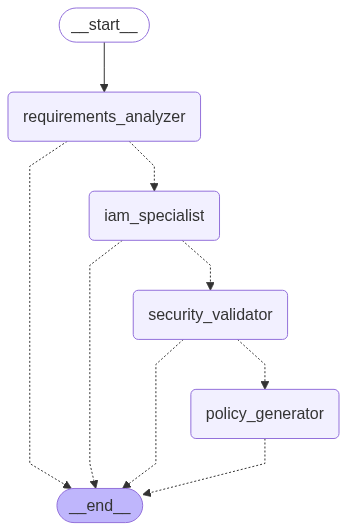

 Workflow diagram displayed above


In [6]:
# Build the LangGraph Workflow

def route_next_agent(state: AgentState) -> str:
    """
    Determine the next agent to run based on current state.
    """
    current_service = state.get("current_service", "")

    if current_service == "":
        return "requirements_analyzer"
    elif current_service == "requirements_analyzed":
        return "iam_specialist"
    elif current_service == "iam_roles_generated":
        return "security_validator"
    elif current_service == "validation_complete":
        return "policy_generator"
    elif current_service == "policy_generated":
        return END
    else:
        return END

# Create the workflow graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("requirements_analyzer", requirements_analyzer_agent)
workflow.add_node("iam_specialist", iam_specialist_agent)
workflow.add_node("security_validator", security_validator_agent)
workflow.add_node("policy_generator", policy_generator_agent)

# Add edges
workflow.add_conditional_edges(
    "requirements_analyzer",
    route_next_agent,
    {
        "iam_specialist": "iam_specialist",
        END: END
    }
)

workflow.add_conditional_edges(
    "iam_specialist",
    route_next_agent,
    {
        "security_validator": "security_validator",
        END: END
    }
)

workflow.add_conditional_edges(
    "security_validator",
    route_next_agent,
    {
        "policy_generator": "policy_generator",
        END: END
    }
)

workflow.add_conditional_edges(
    "policy_generator",
    route_next_agent,
    {
        END: END
    }
)

# Set entry point
workflow.set_entry_point("requirements_analyzer")

# Compile the workflow with memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print(" LangGraph workflow compiled successfully!")
print(" Workflow structure:")
print("  1. Requirements Analyzer → 2. IAM Specialist → 3. Security Validator → 4. Policy Generator")

# Visualize the workflow (if graphviz is available)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
    print(" Workflow diagram displayed above")
except Exception as e:
    print(f" Workflow diagram not available: {e}")
    print(" Install graphviz and pygraphviz to see the visual workflow")

In [15]:
# Helper Functions and Testing

def run_iam_analysis(user_request: str, thread_id: str = "default") -> Dict[str, Any]:
    """
    Run the complete IAM analysis workflow for a user request.

    Args:
        user_request: User's request for GCP service permissions
        thread_id: Unique identifier for the conversation thread

    Returns:
        Complete analysis results
    """
    try:
        # Initialize state
        initial_state = {
            "messages": [HumanMessage(content=user_request)],
            "service_requirements": [],
            "generated_roles": [],
            "validation_results": {},
            "final_recommendations": {},
            "current_service": "",
            "error_messages": []
        }

        # Run the workflow
        config = {"configurable": {"thread_id": thread_id}}
        result = app.invoke(initial_state, config)

        return result

    except Exception as e:
        return {"error": f"Workflow execution error: {str(e)}"}

def format_policy_output(policy_data: Dict[str, Any]) -> str:
    """
    Format the policy output for better readability.
    """
    if "error" in policy_data:
        return f"❌ Error: {policy_data['error']}"

    output = "\\n" + "="*60 + "\\n"
    output += "🎯 GCP IAM POLICY RECOMMENDATIONS\\n"
    output += "="*60 + "\\n\\n"

    # Metadata
    metadata = policy_data.get("metadata", {})
    output += "📊 POLICY SUMMARY:\\n"
    output += f"   • Account Type: {policy_data.get('account_type', 'service_account')}\\n"
    output += f"   • Services Covered: {', '.join(metadata.get('services_covered', []))}\\n"
    output += f"   • Total Roles: {metadata.get('total_roles', 0)}\\n"
    output += f"   • Total Permissions: {metadata.get('total_permissions', 0)}\\n"
    output += f"   • Private Network Optimized: {metadata.get('private_network_optimized', False)}\\n\\n"

    # Key roles
    summary = policy_data.get("summary", {})
    output += "🔑 RECOMMENDED IAM ROLES:\\n"
    for i, role in enumerate(summary.get("roles", []), 1):
        output += f"   {i}. {role}\\n"
    output += "\\n"

    # Key permissions
    output += "🛡️ KEY PERMISSIONS:\\n"
    for i, perm in enumerate(summary.get("key_permissions", [])[:10], 1):  # Show first 10
        output += f"   {i}. {perm}\\n"

    if len(summary.get("key_permissions", [])) > 10:
        output += f"   ... and {len(summary.get('key_permissions', [])) - 10} more permissions\\n"

    output += "\\n" + "="*60 + "\\n"
    output += "💡 IMPLEMENTATION STEPS:\\n"
    output += "   1. Create a service account in your GCP project\\n"
    output += "   2. Assign the recommended roles to the service account\\n"
    output += "   3. Configure VPC and private network settings\\n"
    output += "   4. Test access to each service without public IPs\\n"
    output += "   5. Monitor and audit permissions regularly\\n"
    output += "="*60 + "\\n"

    return output

def display_workflow_results(result: Dict[str, Any]):
    """
    Display comprehensive workflow results.
    """
    print("\\n🚀 WORKFLOW EXECUTION COMPLETED\\n")

    # Display messages
    messages = result.get("messages", [])
    for i, msg in enumerate(messages):
        msg.pretty_print()
        # if isinstance(msg, HumanMessage):
        #     print(f"👤 User Request: {msg.content}")
        # elif isinstance(msg, AIMessage):
        #     print(f"🤖 Agent {i}: {msg.content}")
        print("-" * 50)

    # Display errors if any
    errors = result.get("error_messages", [])
    if errors:
        print("\\n⚠️ ERRORS ENCOUNTERED:")
        for error in errors:
            print(f"   • {error}")

    # Display final policy
    final_policy = result.get("final_recommendations", {})
    if final_policy and "error" not in final_policy:
        print(format_policy_output(final_policy))
    elif final_policy:
        print(f"\\n❌ Policy Generation Error: {final_policy.get('error', 'Unknown error')}")

print("✅ Helper functions created successfully!")
print("🧪 Ready to test the workflow with real requests")

✅ Helper functions created successfully!
🧪 Ready to test the workflow with real requests


In [16]:
# Test the Workflow with Example Requests

# Test Case 1: Comprehensive service request
test_request_1 = """
I need to set up a service account that can work with Vertex AI for machine learning,
Compute Engine for running training jobs, Cloud Storage for data storage, BigQuery for
data analysis, Cloud Build for CI/CD, and Cloud Run for serving models. The service
account should have write access to these services and must work without public IP
addresses for security reasons.
"""

print("🧪 TEST CASE 1: Comprehensive Multi-Service Request")
print("=" * 60)
print(f"Request: {test_request_1.strip()}")
print("=" * 60)

# Run the analysis
result_1 = run_iam_analysis(test_request_1, "test_1")
display_workflow_results(result_1)

🧪 TEST CASE 1: Comprehensive Multi-Service Request
Request: I need to set up a service account that can work with Vertex AI for machine learning,
Compute Engine for running training jobs, Cloud Storage for data storage, BigQuery for
data analysis, Cloud Build for CI/CD, and Cloud Run for serving models. The service
account should have write access to these services and must work without public IP
addresses for security reasons.
\n🚀 WORKFLOW EXECUTION COMPLETED\n
================================ Human Message =================================


I need to set up a service account that can work with Vertex AI for machine learning,
Compute Engine for running training jobs, Cloud Storage for data storage, BigQuery for
data analysis, Cloud Build for CI/CD, and Cloud Run for serving models. The service
account should have write access to these services and must work without public IP
addresses for security reasons.

--------------------------------------------------
==========================

In [9]:
# Additional Test Cases

# Test Case 2: Specific service with admin access
test_request_2 = """
I need admin access to Vertex AI and BigQuery for a data science project.
The setup should be secure with no public IP requirements.
"""

print("\\n\\n🧪 TEST CASE 2: Specific Services with Admin Access")
print("=" * 60)
print(f"Request: {test_request_2.strip()}")
print("=" * 60)

result_2 = run_iam_analysis(test_request_2, "test_2")
display_workflow_results(result_2)

\n\n🧪 TEST CASE 2: Specific Services with Admin Access
Request: I need admin access to Vertex AI and BigQuery for a data science project.
The setup should be secure with no public IP requirements.
\n🚀 WORKFLOW EXECUTION COMPLETED\n
👤 User Request: 
I need admin access to Vertex AI and BigQuery for a data science project.
The setup should be secure with no public IP requirements.

--------------------------------------------------
🤖 Agent 1: Requirements Analysis:
**Structured Analysis**

**Services Needed:**

1. Vertex AI
2. BigQuery

**Access Level for Each Service:**

1. Vertex AI: admin
2. BigQuery: admin

**Specific Requirements:**

* Private network requirements: Yes, no public IP addresses are required.
* Note: As the request requires admin access to Vertex AI and BigQuery, it is assumed that the user needs to manage and configure these services, which may involve creating and managing resources, such as models, datasets, and queries.
---------------------------------------------

In [10]:
# Interactive Usage - Try Your Own Request

def analyze_custom_request():
    """
    Interactive function to analyze custom IAM requests.
    """
    print("🎯 CUSTOM IAM ANALYSIS")
    print("=" * 50)
    print("Enter your GCP service requirements below:")
    print("Example: 'I need to deploy ML models using Vertex AI and Cloud Run with read access to BigQuery'")
    print("=" * 50)

    # In a Jupyter environment, you can modify this to get user input
    # For demonstration, we'll use a predefined request
    custom_request = """
    I need a service account for a DevOps pipeline that can:
    - Build applications using Cloud Build
    - Deploy to Cloud Run
    - Read from Cloud Storage for artifacts
    - Write logs to BigQuery
    All operations should be done without public IP addresses for security.
    """

    print(f"📝 Analyzing request: {custom_request.strip()}")
    print("\\n🔄 Processing...")

    result = run_iam_analysis(custom_request, "custom_request")
    display_workflow_results(result)

    return result

# Run the custom analysis
custom_result = analyze_custom_request()

🎯 CUSTOM IAM ANALYSIS
Enter your GCP service requirements below:
Example: 'I need to deploy ML models using Vertex AI and Cloud Run with read access to BigQuery'
📝 Analyzing request: I need a service account for a DevOps pipeline that can:
    - Build applications using Cloud Build
    - Deploy to Cloud Run
    - Read from Cloud Storage for artifacts
    - Write logs to BigQuery
    All operations should be done without public IP addresses for security.
\n🔄 Processing...
\n🚀 WORKFLOW EXECUTION COMPLETED\n
👤 User Request: 
    I need a service account for a DevOps pipeline that can:
    - Build applications using Cloud Build
    - Deploy to Cloud Run
    - Read from Cloud Storage for artifacts
    - Write logs to BigQuery
    All operations should be done without public IP addresses for security.
    
--------------------------------------------------
🤖 Agent 1: Requirements Analysis:
**Structured Analysis**

**Services Needed:**

1. Cloud Build
2. Cloud Run
3. Cloud Storage
4. BigQuery

In [17]:
# Validation and Best Practices

def validate_permissions_manually(service: str, permissions: List[str]) -> Dict[str, Any]:
    """
    Manual validation function to check if permissions are appropriate for a service.
    """
    validation_report = {
        "service": service,
        "total_permissions": len(permissions),
        "security_level": "unknown",
        "recommendations": [],
        "potential_issues": []
    }

    # Check for overly broad permissions
    broad_permissions = [p for p in permissions if '*' in p or 'admin' in p.lower()]
    if broad_permissions:
        validation_report["potential_issues"].append(
            f"Found broad permissions that might be overly permissive: {broad_permissions}"
        )
        validation_report["security_level"] = "high_risk"

    # Check for service-specific permissions
    service_prefix = {
        "vertex_ai": "aiplatform.",
        "compute_engine": "compute.",
        "cloud_storage": "storage.",
        "bigquery": "bigquery.",
        "cloud_build": "cloudbuild.",
        "cloud_run": "run."
    }

    expected_prefix = service_prefix.get(service, "")
    if expected_prefix:
        relevant_perms = [p for p in permissions if p.startswith(expected_prefix)]
        if len(relevant_perms) < len(permissions) * 0.5:
            validation_report["potential_issues"].append(
                f"Many permissions don't seem specific to {service}"
            )

    # Security score calculation
    if validation_report["potential_issues"]:
        validation_report["security_level"] = "needs_review"
    else:
        validation_report["security_level"] = "good"

    # Generate recommendations
    if broad_permissions:
        validation_report["recommendations"].append(
            "Consider using more specific roles instead of admin or wildcard permissions"
        )

    validation_report["recommendations"].append(
        "Regularly audit and rotate service account keys"
    )
    validation_report["recommendations"].append(
        "Use VPC Service Controls for additional network security"
    )

    return validation_report

# Test validation with generated permissions
print("🔍 PERMISSION VALIDATION EXAMPLE")
print("=" * 50)

# Example validation
if 'result_1' in locals() and result_1.get('generated_roles'):
    first_role = result_1['generated_roles'][0]
    validation = validate_permissions_manually(first_role.service, first_role.permissions)

    print(f"Service: {validation['service']}")
    print(f"Total Permissions: {validation['total_permissions']}")
    print(f"Security Level: {validation['security_level']}")
    print(f"\\nPotential Issues:")
    for issue in validation['potential_issues']:
        print(f"  ⚠️  {issue}")
    print(f"\\nRecommendations:")
    for rec in validation['recommendations']:
        print(f"  💡 {rec}")
else:
    print("Run the test cases above first to see validation results")

🔍 PERMISSION VALIDATION EXAMPLE
Service: compute_engine
Total Permissions: 3
Security Level: needs_review
\nPotential Issues:
  ⚠️  Found broad permissions that might be overly permissive: ['compute.instances.*', 'compute.disks.*']
\nRecommendations:
  💡 Consider using more specific roles instead of admin or wildcard permissions
  💡 Regularly audit and rotate service account keys
  💡 Use VPC Service Controls for additional network security
